#  Calcul de l'Élasticité Prix

## Objectif
Calculer l'élasticité prix pour chaque catégorie de produit.  
L'élasticité mesure la sensibilité des ventes à un changement de prix.

## Interprétation
| Élasticité | Signification | Action |
|---|---|---|
| Entre 0 et -1 | Peu sensible au prix |  Opportunité d'augmenter les prix |
| Entre -1 et -2 | Moyennement sensible |  Augmentation prudente |
| Inférieure à -2 | Très sensible au prix |  Ne pas augmenter les prix |

## Méthode
On va commencé avec une régression linéaire en échelle logarithmique car c'est un standard en économie et la relation prix/ventes est rarement linéaire mais souvent log-linéaire.

## 1. Chargement des données nettoyées

On repart du fichier `df_clean.csv` produit dans le notebook 02.

In [1]:
# ============================================================
# IMPORTS ET CHARGEMENT DES DONNÉES NETTOYÉES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

# Chargement du fichier nettoyé
df = pd.read_csv('../data/df_clean.csv')

print(" Données chargées")
print(f"   - Lignes      : {df.shape[0]:,}")
print(f"   - Colonnes    : {df.columns.tolist()}")
print(f"   - Catégories  : {df['categorie'].nunique()}")

 Données chargées
   - Lignes      : 108,660
   - Colonnes    : ['commande_id', 'produit_id', 'prix', 'frais_livraison', 'note_client', 'categorie']
   - Catégories  : 73


## 2. Calcul de l'élasticité prix par catégorie

### Méthode
Pour chaque catégorie :
1. On divise les prix en 10 tranches égales (quantiles)
2. On calcule le prix moyen et le nombre de ventes par tranche
3. On applique une régression linéaire sur les logarithmes
4. Le coefficient de la régression = l'élasticité

### Pourquoi les logarithmes ?
En économie, la relation prix/ventes suit rarement une droite.
En passant en log, on transforme cette relation courbe en droite,
ce qui permet d'utiliser une régression linéaire simple.

In [2]:
# ============================================================
# FONCTION DE CALCUL D'ÉLASTICITÉ
# ============================================================

def calculer_elasticite(df_categorie, nb_tranches=10):
    """
    Calcule l'élasticité prix d'une catégorie de produits.
    
    Paramètres :
    - df_categorie : DataFrame filtré sur une catégorie
    - nb_tranches  : nombre de tranches de prix (défaut : 10)
    
    Retourne :
    - elasticite : float (coefficient de la régression)
    - r2         : float (qualité du modèle, entre 0 et 1)
    - data       : DataFrame des tranches avec prix moyen et ventes
    """
    
    # Étape 1 : création des tranches de prix
    df_categorie = df_categorie.copy()
    df_categorie['tranche_prix'] = pd.qcut(
        df_categorie['prix'], 
        q=nb_tranches, 
        duplicates='drop'  # Ignore les tranches vides
    )
    
    # Étape 2 : calcul des prix moyen et ventes par tranche
    data = (df_categorie.groupby('tranche_prix', observed=True)
                        .agg(
                            prix_moyen=('prix', 'mean'),
                            nb_ventes=('commande_id', 'count')
                        )
                        .reset_index())
    
    # Étape 3 : passage en logarithme
    # On ajoute 1 aux ventes pour éviter log(0)
    X = np.log(data['prix_moyen']).values.reshape(-1, 1)
    y = np.log(data['nb_ventes'] + 1).values
    
    # Étape 4 : régression linéaire
    model = LinearRegression()
    model.fit(X, y)
    
    elasticite = model.coef_[0]  # Le coefficient = élasticité
    r2 = model.score(X, y)       # Qualité du modèle (0 à 1)
    
    return elasticite, r2, data

# Test sur une catégorie
cat_test = df[df['categorie'] == 'Montres & Cadeaux']
elasticite, r2, data = calculer_elasticite(cat_test)

print(f"=== Test sur 'Montres & Cadeaux' ===")
print(f"Élasticité : {elasticite:.3f}")
print(f"R²         : {r2:.3f}")
print(f"\nDonnées par tranche :")
print(data.to_string(index=False))

=== Test sur 'Montres & Cadeaux' ===
Élasticité : -0.011
R²         : 0.005

Données par tranche :
      tranche_prix  prix_moyen  nb_ventes
     (8.989, 38.0]   29.255203        590
      (38.0, 55.0]   49.478054        776
      (55.0, 78.0]   69.501093        421
     (78.0, 105.0]   97.011506        591
   (105.0, 128.99]  115.578861        553
  (128.99, 155.97]  143.175289        605
  (155.97, 190.83]  173.295690        594
 (190.83, 229.994]  211.365961        557
(229.994, 479.838]  302.554608        586
 (479.838, 3999.9]  811.307235        586


> **Test sur 'Montres & Cadeaux' :**
> - Élasticité de -0.011 ≈ 0 donc les ventes sont quasi insensibles au prix
> - Les ventes restent stables entre 420 et 776 unités (quantités vendues) quelle que soit la tranche de prix
> - R² très faible (0.005) donc le modèle explique seulement 0.5% de la variation. Ce qui veut dire que le prix n'explique pas les variations de ventes
> - Cette catégorie sera idéale pour une augmentation de prix.

## 3. Calcul pour toutes les catégories

On applique la fonction sur les 73 catégories.  
On filtre les catégories avec moins de 100 ventes  
car trop peu de données donnent des élasticités peu fiables.

In [3]:
# ============================================================
# CALCUL DE L'ÉLASTICITÉ POUR TOUTES LES CATÉGORIES
# ============================================================

resultats = []

for categorie in df['categorie'].unique():
    
    # Filtrage des données de la catégorie
    df_cat = df[df['categorie'] == categorie]
    
    # On ignore les catégories avec moins de 100 ventes
    if len(df_cat) < 100:
        continue
    
    # Calcul de l'élasticité
    try:
        elasticite, r2, _ = calculer_elasticite(df_cat)
        resultats.append({
            'categorie'  : categorie,
            'elasticite' : round(elasticite, 3),
            'r2'         : round(r2, 3),
            'nb_ventes'  : len(df_cat),
            'prix_moyen' : round(df_cat['prix'].mean(), 2)
        })
    except Exception as e:
        print(f" Erreur sur {categorie} : {e}")

# Convertir en DataFrame et trier par élasticité
resultats_df = pd.DataFrame(resultats)
resultats_df = resultats_df.sort_values('elasticite', ascending=False).reset_index(drop=True)

print(f" Élasticité calculée pour {len(resultats_df)} catégories")
print(f"\n=== Top 10 catégories les moins élastiques (opportunités) ===")
print(resultats_df.head(10).to_string(index=False))

print(f"\n=== Top 10 catégories les plus élastiques (risquées) ===")
print(resultats_df.tail(10).to_string(index=False))

 Élasticité calculée pour 53 catégories

=== Top 10 catégories les moins élastiques (opportunités) ===
             categorie  elasticite    r2  nb_ventes  prix_moyen
           Ordinateurs       0.018 0.000        199     1098.92
       Téléphonie Fixe       0.001 0.000        255      216.92
        Électroménager      -0.003 0.000        754      104.55
Instruments de Musique      -0.004 0.001        651      283.13
   Ustensiles Ménagers      -0.004 0.034       6795       90.60
 Valises & Accessoires      -0.005 0.027       1077      128.79
          Alimentation      -0.007 0.000        499       57.58
       Consoles & Jeux      -0.007 0.001       1089      135.91
            Automobile      -0.011 0.027       4140      139.85
     Montres & Cadeaux      -0.011 0.005       5859      199.04

=== Top 10 catégories les plus élastiques (risquées) ===
             categorie  elasticite    r2  nb_ventes  prix_moyen
                 Audio      -0.061 0.013        362      139.70
       

> **Observations globales :**
> - 53 catégories analysées (20 exclues car moins de 100 ventes).
> - Toutes les élasticités sont entre 0 et -0.2 donc ce marché est globalement peu sensible aux prix.
> - Meilleures opportunités : Ordinateurs, Téléphonie Fixe, Électroménager, Ustensiles Ménagers.
> - Catégories à risque : Outils & Bricolage (-0.172), Chaussures (-0.159), Outils & Jardin (-0.122).
> - Le R² est faibles partout donc le prix seul n'explique pas les ventes (Ce qui est tout affaire normal en e-commerce).

## 4. Visualisation des élasticités

On va visualiser un peu les élasticités de toutes les catégories pour identifier rapidement les opportunités et les risques.

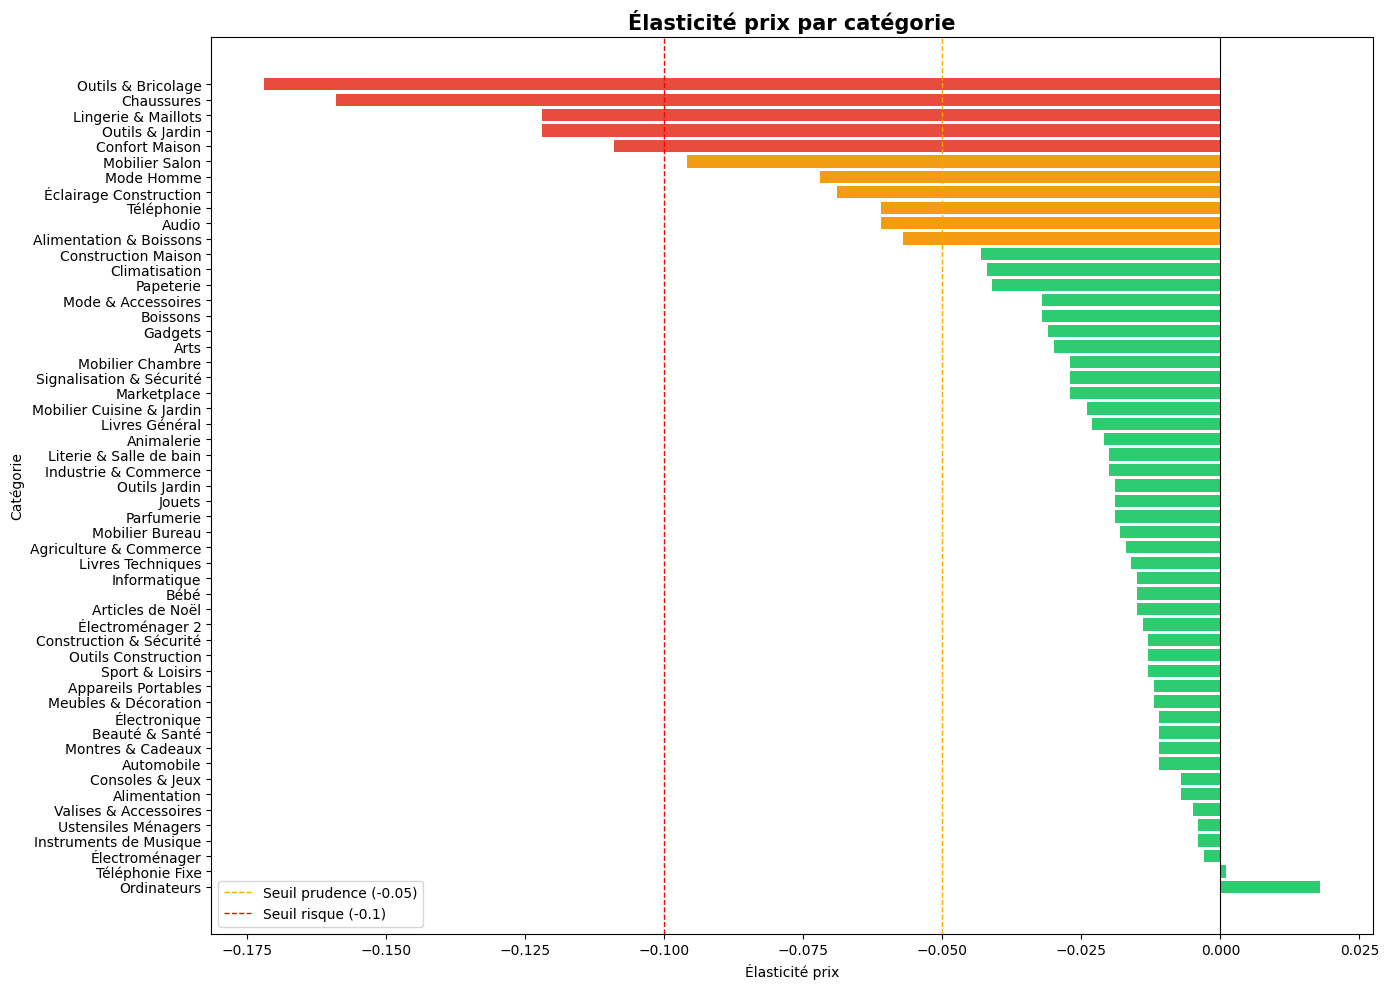

 Graphique sauvegardé dans outputs/


In [4]:
# ============================================================
# VISUALISATION DES ÉLASTICITÉS
# ============================================================

plt.figure(figsize=(14, 10))

# Couleur selon opportunité ou risque
couleurs = ['#2ecc71' if e > -0.05 else '#e74c3c' if e < -0.1 
            else '#f39c12' for e in resultats_df['elasticite']]

# Graphique horizontal
bars = plt.barh(resultats_df['categorie'], 
                resultats_df['elasticite'],
                color=couleurs)

# Ligne verticale à 0
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.8)

# Lignes de seuil
plt.axvline(x=-0.05, color='orange', linestyle='--', 
            linewidth=1, label='Seuil prudence (-0.05)')
plt.axvline(x=-0.1, color='red', linestyle='--', 
            linewidth=1, label='Seuil risque (-0.1)')

plt.title('Élasticité prix par catégorie', fontsize=15, fontweight='bold')
plt.xlabel('Élasticité prix')
plt.ylabel('Catégorie')
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/elasticite_par_categorie.png', dpi=150)
plt.show()

print(" Graphique sauvegardé dans outputs/")

> **Lecture du graphique :**
> - 🟢  La Majorité des catégories sont en vert (élasticité > -0.05) donc on peut augmenter les prix sans risque majeur. Les meilleures catégories sont : Ordinateurs, Téléphonie Fixe, Électroménager, Ustensiles Ménagers.
> - 🟡 9 catégories en orange (élasticité entre -0.05 et -0.1), une augmentation est possible mais avec prudence (max +5%).
> - 🔴 5 catégories en rouge (élasticité < -0.1) catégories à risque, ne pas augmenter les prix.

## 5. Export des résultats

On sauvegarde le tableau des élasticités pour l'utiliser prochainement dans l'optimisation des prix.

In [5]:
# ============================================================
# EXPORT DES RÉSULTATS
# ============================================================

# Ajoute d'une colonne pour catégoriser les opportunités
def classifier_opportunite(elasticite):
    if elasticite > -0.05:
        return '🟢 Opportunité'
    elif elasticite > -0.1:
        return '🟡 Prudence'
    else:
        return '🔴 Risque'

resultats_df['opportunite'] = resultats_df['elasticite'].apply(classifier_opportunite)

# Affichage du résumé
print("=== Résumé des opportunités ===")
print(resultats_df['opportunite'].value_counts())

# Export
resultats_df.to_csv('../data/elasticites.csv', index=False)
print("\n Fichier exporté : data/elasticites.csv")
print(f"   {len(resultats_df)} catégories analysées")

=== Résumé des opportunités ===
opportunite
🟢 Opportunité    42
🟡 Prudence        6
🔴 Risque          5
Name: count, dtype: int64

 Fichier exporté : data/elasticites.csv
   53 catégories analysées


## 6. Conclusion

### Résultats
| Segment | Nb catégories | Action recommandée |
|---|---|---|
| 🟢 Opportunité (élasticité > -0.05) | 42 | Augmentation de prix possible |
| 🟡 Prudence (entre -0.05 et -0.1) | 6 | Augmentation modérée (max +5%) |
| 🔴 Risque (élasticité < -0.1) | 5 | Ne pas augmenter les prix |

### Points clés
- 79% des catégories sont peu sensibles aux prix ce qui promet un fort potentiel d'optimisation.
- Les R² faibles confirment que d'autres facteurs influencent les ventes.
- Les résultats sont exportés dans `data/elasticites.csv`

### Prochaine étape
On va essayé de calculer le prix optimal par catégorie et simuler l'impact sur le chiffre d'affaires.